# Football Match Outcome Prediction

**Dataset:** `football_matches_2024_2025.csv`  


## Project Description

Project ini menggunakan dataset pertandingan sepak bola musim 2024/2025. Dataset berisi informasi pertandingan seperti kompetisi, tanggal pertandingan, tim tuan rumah, tim tamu, wasit, skor, dan hasil akhir pertandingan.

Tujuan project adalah membangun pipeline awal untuk **memprediksi hasil pertandingan sepak bola** berdasarkan informasi pertandingan yang tersedia di dataset.

Target prediksi yang digunakan adalah kolom:

`match_outcome`

Target tersebut memiliki 3 kategori:

- `Home Win`: tim tuan rumah menang
- `Away Win`: tim tamu menang
- `Draw`: pertandingan seri


## Case Study

**Studi kasus:**  
Sebuah sistem analisis sepak bola ingin membantu memprediksi kemungkinan hasil pertandingan berdasarkan data historis pertandingan. Prediksi ini dapat digunakan sebagai dasar analisis performa tim, evaluasi pertandingan, atau bahan eksperimen model klasifikasi.

Pada tahap ini, kita menyiapkan data agar siap digunakan untuk pelatihan model. Tahapan preprocessing meliputi:

1. Load dataset menggunakan pandas.
2. Menampilkan informasi dataset.
3. Mengecek missing value.
4. Memilih fitur dan target.
5. Melakukan encoding data kategori.
6. Membagi data menjadi training dan testing.
7. Melakukan normalisasi data.

**Catatan penting:**  
Kolom hasil pertandingan seperti `fulltime_home`, `fulltime_away`, `halftime_home`, `halftime_away`, `goal_difference`, `total_goals`, `home_points`, dan `away_points` tidak digunakan sebagai fitur utama karena kolom tersebut berisi informasi setelah pertandingan selesai. Jika kolom tersebut digunakan untuk memprediksi `match_outcome`, model bisa terlalu mudah menebak hasil karena terjadi *data leakage*.


# Langkah 1 — Preprocessing Data

## 1. Import Library

In [31]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

pd.set_option("display.max_columns", None)


## 2. Load Dataset Menggunakan Pandas

In [32]:
# Nama file dataset
DATASET_NAME = "football_matches_2024_2025.csv"

# Cek apakah file ada di folder kerja saat ini
if os.path.exists(DATASET_NAME):
    data_path = DATASET_NAME
else:
    # Fallback khusus Google Colab: upload file secara manual
    try:
        from google.colab import files
        print("File dataset belum ditemukan. Silakan upload file CSV.")
        uploaded = files.upload()
        data_path = list(uploaded.keys())[0]
    except ModuleNotFoundError:
        raise FileNotFoundError(
            f"File {DATASET_NAME} belum ditemukan. "
            "Pastikan file CSV berada di folder yang sama dengan notebook."
        )

df = pd.read_csv(data_path)

print("Dataset berhasil dimuat.")
print("Jumlah baris dan kolom:", df.shape)

df.head()


Dataset berhasil dimuat.
Jumlah baris dan kolom: (1941, 23)


,competition_code,competition_name,season,match_id,matchday,stage,status,date_utc,referee,home_team_id,home_team,away_team_id,away_team,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals,match_outcome,home_points,away_points,referee_id
0,PL,Premier League,2024/2025,497410,1,REGULAR_SEASON,FINISHED,2024-08-16 19:00:00+00:00,Robert Jones,66,Manchester United FC,63,Fulham FC,1,0,0,0,1,1,Home Win,3,0,1
1,PL,Premier League,2024/2025,497411,1,REGULAR_SEASON,FINISHED,2024-08-17 11:30:00+00:00,Tim Robinson,349,Ipswich Town FC,64,Liverpool FC,0,2,0,0,-2,2,Away Win,0,3,2
2,PL,Premier League,2024/2025,497412,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Jarred Gillett,57,Arsenal FC,76,Wolverhampton Wanderers FC,2,0,1,0,2,2,Home Win,3,0,3
3,PL,Premier League,2024/2025,497413,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Simon Hooper,62,Everton FC,397,Brighton & Hove Albion FC,0,3,0,1,-3,3,Away Win,0,3,4
4,PL,Premier League,2024/2025,497414,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Craig Pawson,67,Newcastle United FC,340,Southampton FC,1,0,1,0,1,1,Home Win,3,0,5


## 3. Menampilkan Informasi Dataset

In [33]:
# Melihat informasi umum dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   competition_code  1941 non-null   object
 1   competition_name  1941 non-null   object
 2   season            1941 non-null   object
 3   match_id          1941 non-null   int64 
 4   matchday          1941 non-null   int64 
 5   stage             1941 non-null   object
 6   status            1941 non-null   object
 7   date_utc          1941 non-null   object
 8   referee           1941 non-null   object
 9   home_team_id      1941 non-null   int64 
 10  home_team         1941 non-null   object
 11  away_team_id      1941 non-null   int64 
 12  away_team         1941 non-null   object
 13  fulltime_home     1941 non-null   int64 
 14  fulltime_away     1941 non-null   int64 
 15  halftime_home     1941 non-null   int64 
 16  halftime_away     1941 non-null   int64 
 17  goal_differenc

In [34]:
# Melihat nama kolom dan tipe data
info_dataset = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Unique Values": df.nunique().values
})

info_dataset


,Column,Data Type,Unique Values
competition_code,competition_code,object,6
competition_name,competition_name,object,6
season,season,object,1
match_id,match_id,int64,1941
matchday,matchday,int64,39
stage,stage,object,7
status,status,object,2
date_utc,date_utc,object,1109
referee,referee,object,158
home_team_id,home_team_id,int64,110


In [35]:
# Statistik deskriptif untuk data numerik
df.describe()


,match_id,matchday,home_team_id,away_team_id,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals,home_points,away_points,referee_id
count,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,502366.762494,17.337970,483.205564,482.991242,1.535806,1.340031,0.699639,0.588357,0.195775,2.875837,1.524472,1.236991,65.609995
std,7461.271565,11.057402,1170.086272,1170.116895,1.322829,1.205567,0.860319,0.790438,1.880667,1.693997,1.331631,1.305615,42.866261
min,497410.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,-6.000000,0.000000,0.000000,0.000000,-1.000000
25%,498056.000000,7.000000,67.000000,67.000000,1.000000,0.000000,0.000000,0.000000,-1.000000,2.000000,0.000000,0.000000,29.000000
50%,498897.000000,17.000000,109.000000,109.000000,1.000000,1.000000,1.000000,0.000000,0.000000,3.000000,1.000000,1.000000,61.000000
75%,503126.000000,27.000000,522.000000,522.000000,2.000000,2.000000,1.000000,1.000000,1.000000,4.000000,3.000000,3.000000,104.000000
max,524120.000000,38.000000,7509.000000,7509.000000,9.000000,7.000000,6.000000,5.000000,8.000000,11.000000,3.000000,3.000000,157.000000


In [36]:
# Statistik deskriptif untuk data kategori
df.describe(include="object")


,competition_code,competition_name,season,stage,status,date_utc,referee,home_team,away_team,match_outcome
count,1941,1941,1941,1941,1941,1941,1941,1941,1941,1941
unique,6,6,1,7,2,1109,158,110,110,3
top,PL,Premier League,2024/2025,REGULAR_SEASON,FINISHED,2025-01-29 20:00:00+00:00,Michael Oliver,Arsenal FC,FC Internazionale Milano,Home Win
freq,380,380,1941,1752,1939,18,34,26,27,832


## 4. Mengecek Missing Value

In [37]:
missing_values = pd.DataFrame({
    "Missing Value": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values


,Missing Value,Percentage (%)
competition_code,0,0.0
competition_name,0,0.0
season,0,0.0
match_id,0,0.0
matchday,0,0.0
stage,0,0.0
status,0,0.0
date_utc,0,0.0
referee,0,0.0
home_team_id,0,0.0


In [38]:
# Menampilkan total missing value
total_missing = df.isnull().sum().sum()
print("Total missing value:", total_missing)


Total missing value: 0


## 5. Memilih Fitur dan Target

Target yang dipilih adalah `match_outcome` karena project ini berupa klasifikasi hasil pertandingan.

Fitur yang digunakan adalah fitur yang masih relevan sebelum hasil akhir pertandingan diketahui, seperti kompetisi, matchday, stage, tim, wasit, dan informasi waktu pertandingan.

Kolom skor akhir dan poin tidak digunakan karena dapat menyebabkan *data leakage*.


In [39]:
# Mengubah kolom date_utc menjadi datetime
df["date_utc"] = pd.to_datetime(df["date_utc"], errors="coerce", utc=True)

# Membuat fitur tambahan dari tanggal pertandingan
df["match_month"] = df["date_utc"].dt.month
df["match_dayofweek"] = df["date_utc"].dt.dayofweek

# Target
target_col = "match_outcome"

# Kolom kategori yang akan di-encoding
categorical_features = [
    "competition_code",
    "competition_name",
    "stage",
    "status",
    "referee",
    "home_team",
    "away_team"
]

# Kolom numerik yang akan dinormalisasi
numeric_features = [
    "matchday",
    "home_team_id",
    "away_team_id",
    "referee_id",
    "match_month",
    "match_dayofweek"
]

# Fitur dan target
feature_cols = categorical_features + numeric_features

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Jumlah fitur:", len(feature_cols))
print("Fitur yang digunakan:")
print(feature_cols)

print("\nTarget yang digunakan:", target_col)
print("\nDistribusi target:")
print(y.value_counts())


Jumlah fitur: 13
Fitur yang digunakan:
['competition_code', 'competition_name', 'stage', 'status', 'referee', 'home_team', 'away_team', 'matchday', 'home_team_id', 'away_team_id', 'referee_id', 'match_month', 'match_dayofweek']

Target yang digunakan: match_outcome

Distribusi target:
match_outcome
Home Win    832
Away Win    646
Draw        463
Name: count, dtype: int64


## 6. Encoding Data Kategori

Data kategori seperti nama tim, nama kompetisi, stage, status, dan wasit perlu diubah menjadi bentuk numerik agar dapat diproses oleh model Machine Learning.

Pada notebook ini:

- Fitur kategori diubah menggunakan **One-Hot Encoding**.
- Target `match_outcome` diubah menggunakan **Label Encoding**.


In [40]:
# Encoding target menggunakan LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Mapping label target:")
for class_name, class_code in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{class_name} -> {class_code}")

print("\nContoh hasil encoding target:")
pd.DataFrame({
    "match_outcome": y.head(10),
    "encoded_target": y_encoded[:10]
})


Mapping label target:
Away Win -> 0
Draw -> 1
Home Win -> 2

Contoh hasil encoding target:


,match_outcome,encoded_target
0,Home Win,2
1,Away Win,0
2,Home Win,2
3,Away Win,0
4,Home Win,2
5,Draw,1
6,Away Win,0
7,Home Win,2
8,Away Win,0
9,Draw,1


In [41]:
# Membuat OneHotEncoder
# Catatan: sparse_output digunakan di scikit-learn versi baru.
# Jika versi lama, gunakan parameter sparse.
try:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Preprocessor untuk fitur:
# - OneHotEncoder untuk data kategori
# - StandardScaler untuk data numerik
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", onehot_encoder, categorical_features),
        ("numeric", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

preprocessor


ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['competition_code', 'competition_name',
                                  'stage', 'status', 'referee', 'home_team',
                                  'away_team']),
                                ('numeric', StandardScaler(),
                                 ['matchday', 'home_team_id', 'away_team_id',
                                  'referee_id', 'match_month',
                                  'match_dayofweek'])])

## 7. Membagi Data Menjadi Training dan Testing

Data dibagi menjadi:

- 80% data training
- 20% data testing

Parameter `stratify=y_encoded` digunakan agar proporsi kelas target pada data training dan testing tetap seimbang.


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test:", y_test.shape)


Ukuran X_train: (1552, 13)
Ukuran X_test: (389, 13)
Ukuran y_train: (1552,)
Ukuran y_test: (389,)


In [43]:
# Mengecek distribusi target setelah split
train_distribution = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_distribution = pd.Series(y_test).value_counts(normalize=True).sort_index()

distribution_df = pd.DataFrame({
    "Class": label_encoder.classes_,
    "Train Distribution": train_distribution.values.round(3),
    "Test Distribution": test_distribution.values.round(3)
})

distribution_df


,Class,Train Distribution,Test Distribution
0,Away Win,0.333,0.332
1,Draw,0.238,0.239
2,Home Win,0.428,0.429


## 8. Normalisasi Data

Normalisasi dilakukan menggunakan `StandardScaler` untuk fitur numerik.  
Agar preprocessing aman, proses `fit` hanya dilakukan pada data training, lalu data testing hanya ditransform menggunakan scaler/encoder yang sudah dipelajari dari data training.

Pada kode di bawah, encoding dan normalisasi dilakukan sekaligus melalui `ColumnTransformer`.


In [44]:
# Fit hanya pada data training, lalu transform train dan test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape data training setelah preprocessing:", X_train_processed.shape)
print("Shape data testing setelah preprocessing:", X_test_processed.shape)


Shape data training setelah preprocessing: (1552, 402)
Shape data testing setelah preprocessing: (389, 402)


In [45]:
# Mengambil nama kolom hasil one-hot encoding
encoded_cat_cols = preprocessor.named_transformers_["categorical"].get_feature_names_out(categorical_features)
processed_feature_names = list(encoded_cat_cols) + numeric_features

# Mengubah hasil preprocessing ke DataFrame agar mudah dilihat
X_train_processed_df = pd.DataFrame(X_train_processed, columns=processed_feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=processed_feature_names)

X_train_processed_df.head()


,competition_code_BL1,competition_code_CL,competition_code_FL1,competition_code_PD,competition_code_PL,competition_code_SA,competition_name_Bundesliga,competition_name_La Liga,competition_name_Ligue 1,competition_name_Premier League,competition_name_Serie A,competition_name_UEFA Champions League,stage_FINAL,stage_LAST_16,stage_LEAGUE_STAGE,stage_PLAYOFFS,stage_QUARTER_FINALS,stage_REGULAR_SEASON,stage_SEMI_FINALS,status_AWARDED,status_FINISHED,referee_Abdelatif Kherradji,referee_Adrián Cordero Vega,referee_Alejandro Hernández Hernández,referee_Alejandro Muñiz Ruiz,referee_Alejandro Quintero González,referee_Alessandro Prontera,referee_Andrea Colombo,referee_Andrew Kitchen,referee_Andy Madley,referee_Anthony Taylor,referee_Antonio Giua,referee_Antonio Rapuano,referee_Bastian Dankert,referee_Bastien Dechepy,referee_Benjamin Brand,referee_Benoît Bastien,referee_Benoît Millot,referee_Chris Kavanagh,referee_Christian Dingert,referee_Clément Turpin,referee_Craig Pawson,referee_César Soto Grado,referee_Daniel Schlager,referee_Daniel Siebert,referee_Daniele Chiffi,referee_Daniele Doveri,referee_Daniele Perenzoni,referee_Danny Makkelie,referee_Darren Bond,referee_Darren England,referee_David Coote,referee_David Webb,referee_Davide Di Marco,referee_Davide Ghersini,referee_Davide Massa,referee_Deniz Aytekin,referee_Donatas Rumšas,referee_Eric Wattellier,referee_Erik Lambrechts,referee_Ermanno Feliciani,referee_Espen Eskås,referee_Fabio Maresca,referee_Federico Dionisi,referee_Federico La Penna,referee_Felix Brych,referee_Felix Zwayer,referee_Florent Batta,referee_Florian Badstübner,referee_Florian Exner,referee_Francesco Cosso,referee_Francesco Fourneau,referee_Francisco Hernández Maeso,referee_Frank Willenborg,referee_François Letexier,referee_Gaël Angoula,referee_Georgi Kabakov,referee_Gianluca Aureliano,referee_Gianluca Manganiello,referee_Giorgi Kruashvili,referee_Giovanni Ayroldi,referee_Giuseppe Collu,referee_Glenn Nyberg,referee_Guillermo Cuadra Fernández,referee_Hakim Ben El Hadj Salem,referee_Halil Meler,referee_Harm Osmers,referee_Horațiu Fesnic,referee_Irfan Peljto,referee_Isidro Díaz de Mera,referee_István Kovács,referee_Ivan Kružliak,referee_Jarred Gillett,referee_Javier Alberola Rojas,referee_Jeremy Stinat,referee_Jesús Gil Manzano,referee_John Brooks,referee_Joshua Smith,referee_José Munuera Montero,referee_José Sánchez Martínez,referee_João Pinheiro,referee_Juan Luca Sacchi,referee_Juan Martínez Munuera,referee_Juan Pulido Santana,referee_Jérémie Pignard,referee_Jérôme Brisard,referee_Kevin Bonacina,referee_Lewis Smith,referee_Livio Marinelli,referee_Luca Massimi,referee_Luca Pairetto,referee_Luca Zufferli,referee_Manfredas Lukjančukas,referee_Marc Bollengier,referee_Marco Di Bello,referee_Marco Guida,referee_Marco Monaldi,referee_Marco Piccinini,referee_Maria Caputi,referee_Mario Melero López,referee_Martin Petersen,referee_Mateo Busquets Ferrer,referee_Mathieu Vernice,referee_Matteo Marcenaro,referee_Matteo Marchetti,referee_Matthias Jöllenbeck,referee_Maurizio Mariani,referee_Max Burda,referee_Michael Fabbri,referee_Michael Oliver,referee_Michael Salisbury,referee_Miguel Ortiz Arias,referee_Mikola Balakin,referee_Nick Walsh,referee_Nikola Dabanović,referee_Orel Grinfeld,referee_Pablo González Fuertes,referee_Paride Tremolada,referee_Peter Bankes,referee_Rade Obrenović,referee_Radu Petrescu,referee_Ricardo de Burgos,referee_Robert Hartmann,referee_Robert Jones,referee_Robert Schröder,referee_Robin Braun,referee_Rohit Saggi,referee_Romain Lissorgue,referee_Rosario Abisso,referee_Sam Barrott,referee_Samuel Allison,referee_Sandro Schärer,referee_Sascha Stegemann,referee_Serdar Gözübüyük,referee_Simon Hooper,referee_Simone Sozza,referee_Slavko Vinčič,referee_Stuart Attwell,referee_Stéphanie Frappart,referee_Sven Jablonski,referee_Szymon Marciniak,referee_Sören Storks,referee_Thomas Bramall,referee_Thomas Léonard,referee_Tim Robinson,referee_Timo Gerach,referee_Tobias Reichel,referee_Tobias Stieler,referee_Tobias Welz,refere

## 9. Hasil Akhir Preprocessing

Data sudah siap digunakan untuk tahap modeling, misalnya menggunakan Neural Network sederhana.

Output yang dihasilkan:

- `X_train_processed`
- `X_test_processed`
- `y_train`
- `y_test`
- `label_encoder`
- `preprocessor`


In [46]:
print("Ringkasan hasil akhir:")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed :", X_test_processed.shape)
print("y_train          :", y_train.shape)
print("y_test           :", y_test.shape)

print("\nClass target:")
print(label_encoder.classes_)


Ringkasan hasil akhir:
X_train_processed: (1552, 402)
X_test_processed : (389, 402)
y_train          : (1552,)
y_test           : (389,)

Class target:
['Away Win' 'Draw' 'Home Win']


In [47]:
# Contoh data akhir yang siap masuk ke model
final_train_preview = X_train_processed_df.copy()
final_train_preview["target"] = y_train

final_train_preview.head()


,competition_code_BL1,competition_code_CL,competition_code_FL1,competition_code_PD,competition_code_PL,competition_code_SA,competition_name_Bundesliga,competition_name_La Liga,competition_name_Ligue 1,competition_name_Premier League,competition_name_Serie A,competition_name_UEFA Champions League,stage_FINAL,stage_LAST_16,stage_LEAGUE_STAGE,stage_PLAYOFFS,stage_QUARTER_FINALS,stage_REGULAR_SEASON,stage_SEMI_FINALS,status_AWARDED,status_FINISHED,referee_Abdelatif Kherradji,referee_Adrián Cordero Vega,referee_Alejandro Hernández Hernández,referee_Alejandro Muñiz Ruiz,referee_Alejandro Quintero González,referee_Alessandro Prontera,referee_Andrea Colombo,referee_Andrew Kitchen,referee_Andy Madley,referee_Anthony Taylor,referee_Antonio Giua,referee_Antonio Rapuano,referee_Bastian Dankert,referee_Bastien Dechepy,referee_Benjamin Brand,referee_Benoît Bastien,referee_Benoît Millot,referee_Chris Kavanagh,referee_Christian Dingert,referee_Clément Turpin,referee_Craig Pawson,referee_César Soto Grado,referee_Daniel Schlager,referee_Daniel Siebert,referee_Daniele Chiffi,referee_Daniele Doveri,referee_Daniele Perenzoni,referee_Danny Makkelie,referee_Darren Bond,referee_Darren England,referee_David Coote,referee_David Webb,referee_Davide Di Marco,referee_Davide Ghersini,referee_Davide Massa,referee_Deniz Aytekin,referee_Donatas Rumšas,referee_Eric Wattellier,referee_Erik Lambrechts,referee_Ermanno Feliciani,referee_Espen Eskås,referee_Fabio Maresca,referee_Federico Dionisi,referee_Federico La Penna,referee_Felix Brych,referee_Felix Zwayer,referee_Florent Batta,referee_Florian Badstübner,referee_Florian Exner,referee_Francesco Cosso,referee_Francesco Fourneau,referee_Francisco Hernández Maeso,referee_Frank Willenborg,referee_François Letexier,referee_Gaël Angoula,referee_Georgi Kabakov,referee_Gianluca Aureliano,referee_Gianluca Manganiello,referee_Giorgi Kruashvili,referee_Giovanni Ayroldi,referee_Giuseppe Collu,referee_Glenn Nyberg,referee_Guillermo Cuadra Fernández,referee_Hakim Ben El Hadj Salem,referee_Halil Meler,referee_Harm Osmers,referee_Horațiu Fesnic,referee_Irfan Peljto,referee_Isidro Díaz de Mera,referee_István Kovács,referee_Ivan Kružliak,referee_Jarred Gillett,referee_Javier Alberola Rojas,referee_Jeremy Stinat,referee_Jesús Gil Manzano,referee_John Brooks,referee_Joshua Smith,referee_José Munuera Montero,referee_José Sánchez Martínez,referee_João Pinheiro,referee_Juan Luca Sacchi,referee_Juan Martínez Munuera,referee_Juan Pulido Santana,referee_Jérémie Pignard,referee_Jérôme Brisard,referee_Kevin Bonacina,referee_Lewis Smith,referee_Livio Marinelli,referee_Luca Massimi,referee_Luca Pairetto,referee_Luca Zufferli,referee_Manfredas Lukjančukas,referee_Marc Bollengier,referee_Marco Di Bello,referee_Marco Guida,referee_Marco Monaldi,referee_Marco Piccinini,referee_Maria Caputi,referee_Mario Melero López,referee_Martin Petersen,referee_Mateo Busquets Ferrer,referee_Mathieu Vernice,referee_Matteo Marcenaro,referee_Matteo Marchetti,referee_Matthias Jöllenbeck,referee_Maurizio Mariani,referee_Max Burda,referee_Michael Fabbri,referee_Michael Oliver,referee_Michael Salisbury,referee_Miguel Ortiz Arias,referee_Mikola Balakin,referee_Nick Walsh,referee_Nikola Dabanović,referee_Orel Grinfeld,referee_Pablo González Fuertes,referee_Paride Tremolada,referee_Peter Bankes,referee_Rade Obrenović,referee_Radu Petrescu,referee_Ricardo de Burgos,referee_Robert Hartmann,referee_Robert Jones,referee_Robert Schröder,referee_Robin Braun,referee_Rohit Saggi,referee_Romain Lissorgue,referee_Rosario Abisso,referee_Sam Barrott,referee_Samuel Allison,referee_Sandro Schärer,referee_Sascha Stegemann,referee_Serdar Gözübüyük,referee_Simon Hooper,referee_Simone Sozza,referee_Slavko Vinčič,referee_Stuart Attwell,referee_Stéphanie Frappart,referee_Sven Jablonski,referee_Szymon Marciniak,referee_Sören Storks,referee_Thomas Bramall,referee_Thomas Léonard,referee_Tim Robinson,referee_Timo Gerach,referee_Tobias Reichel,referee_Tobias Stieler,referee_Tobias Welz,refere

## 10. Kesimpulan Preprocessing

Berdasarkan tahapan preprocessing yang sudah dilakukan:

1. Dataset berhasil dimuat menggunakan pandas.
2. Informasi dataset berhasil ditampilkan, termasuk jumlah baris, kolom, tipe data, dan nilai unik.
3. Missing value berhasil dicek.
4. Fitur dan target berhasil dipilih.
5. Data kategori berhasil disiapkan dengan One-Hot Encoding.
6. Target `match_outcome` berhasil diubah menjadi label numerik.
7. Dataset berhasil dibagi menjadi data training dan testing.
8. Fitur numerik berhasil dinormalisasi menggunakan StandardScaler.
9. Data akhir sudah siap digunakan untuk proses training model Machine Learning atau Neural Network.


## Langkah 2 — Model Neural Network

### 1. Import Library

In [48]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 2. Membuat Model Neural Network

Model akan memiliki:
- **Input Layer**: Dengan jumlah neuron sesuai dengan jumlah fitur pada `X_train_processed`.
- **Hidden Layer**: Dua hidden layer dengan 64 dan 32 neuron, menggunakan fungsi aktivasi ReLU.
- **Output Layer**: Tiga neuron untuk 3 kelas target (`Home Win`, `Away Win`, `Draw`), menggunakan fungsi aktivasi Softmax.

In [49]:
# Tentukan jumlah fitur (input_shape)
input_shape = X_train_processed.shape[1]

# Buat model Sequential
model = Sequential([
    Dense(64, activation='relu', input_shape=(input_shape,)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax') # 3 kelas untuk match_outcome
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 3. Compile Model

Model akan dicompile dengan:
- **Optimizer**: `adam`
- **Loss Function**: `sparse_categorical_crossentropy` (karena target `y_encoded` adalah integer label, bukan one-hot encoded).
- **Metrics**: `accuracy`

In [50]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### 4. Training Model

Model akan dilatih menggunakan data training (`X_train_processed`, `y_train`) dan divalidasi dengan data testing (`X_test_processed`, `y_test`).

In [51]:
history = model.fit(
    X_train_processed,
    y_train,
    epochs=20, # Jumlah epoch bisa disesuaikan
    batch_size=32,
    validation_data=(X_test_processed, y_test),
    verbose=1
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4253 - loss: 1.0726 - val_accuracy: 0.4422 - val_loss: 1.0563
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4710 - loss: 1.0251 - val_accuracy: 0.4807 - val_loss: 1.0426
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5380 - loss: 0.9746 - val_accuracy: 0.5193 - val_loss: 1.0175
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6050 - loss: 0.9043 - val_accuracy: 0.5321 - val_loss: 1.0032
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6482 - loss: 0.8214 - val_accuracy: 0.5424 - val_loss: 1.0124
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6849 - loss: 0.7458 - val_accuracy: 0.5219 - val_loss: 1.0187
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7416 - loss: 0.6698 - val_accuracy: 0.5321 - val_loss: 1.0514
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7642 - loss: 0.5945 - val_accuracy: 0.5141 - val_loss:

### 5. Menampilkan Model Summary

Ringkasan model menunjukkan arsitektur model, jumlah parameter, dan output shape dari setiap layer.

In [52]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │        25,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,915 (327.80 KB)

 Trainable params: 27,971 (109.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 55,944 (218.54 KB)

# Langgkah 3 - Evaluasi Model

Pada tahap ini dilakukan evaluasi terhadap model Neural Network yang telah dibuat. Evaluasi dilakukan menggunakan Accuracy, Precision, Recall, F1-Score, Confusion Matrix, serta grafik Accuracy dan Loss.

In [53]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

# Prediksi data testing
y_pred_prob = model.predict(X_test_processed)
y_pred = np.argmax(y_pred_prob, axis=1)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("HASIL EVALUASI MODEL")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
HASIL EVALUASI MODEL
Accuracy : 0.5012853470437018
Precision: 0.49357201752629515
Recall   : 0.5012853470437018
F1-Score : 0.4961601864568802

Classification Report
              precision    recall  f1-score   support

           0       0.51      0.49      0.50       129
           1       0.35      0.30      0.32        93
           2       0.56      0.62      0.59       167

    accuracy                           0.50       389
   macro avg       0.47      0.47      0.47       389
weighted avg       0.49      0.50      0.50       389



## Confusion Matrix

Confusion Matrix digunakan untuk melihat jumlah prediksi yang benar dan salah pada setiap kelas hasil pertandingan.

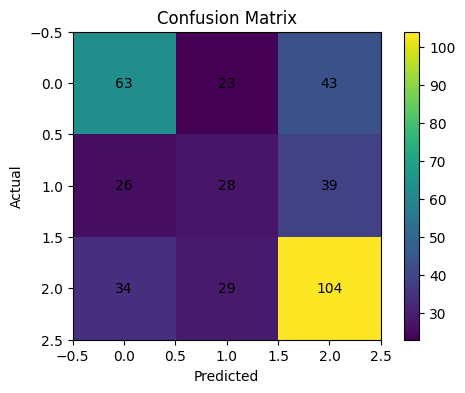

In [54]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center')

plt.show()

## Grafik Accuracy

Grafik Accuracy digunakan untuk melihat perkembangan akurasi model selama proses training.

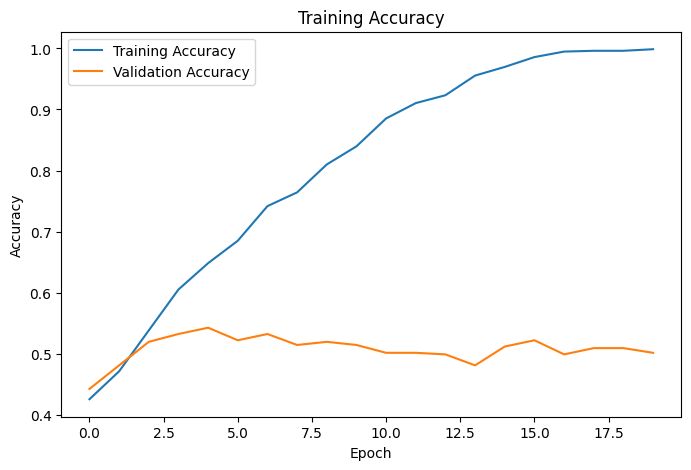

In [55]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.show()

## Grafik Loss

Grafik Loss digunakan untuk melihat perubahan nilai loss selama proses training berlangsung.

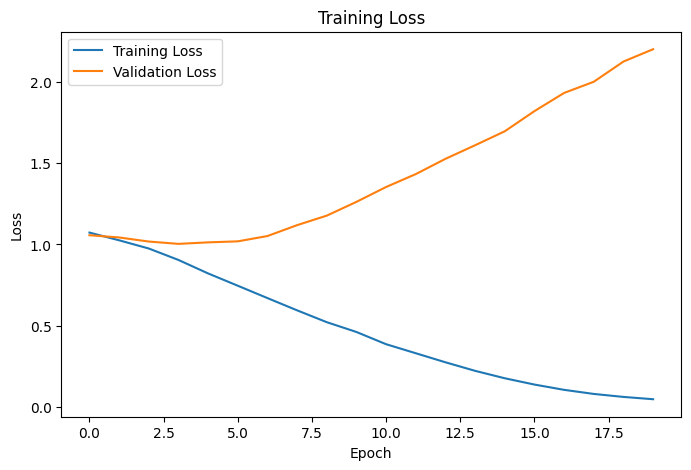

In [56]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.show()

## Kesimpulan

Berdasarkan hasil evaluasi yang dilakukan menggunakan Accuracy, Precision, Recall, dan F1-Score, model Neural Network mampu melakukan klasifikasi hasil pertandingan sepakbola ke dalam tiga kelas yaitu Home Win, Draw, dan Away Win.

Selain itu, Confusion Matrix serta grafik Accuracy dan Loss menunjukkan performa model selama proses pelatihan dan pengujian.